# Review 20 random struts and 20 preliminary gap candidates

This notebook creates two reproducible groups:

- **20 random struts** for an unbiased sample, which will usually be mostly continuous.
- **20 preliminary gap candidates** found by a fast, low-threshold centerline screen.

The preliminary screen is only a way to find interesting structures to inspect. It is not a defect classification. The detailed panels show raw CT evidence without displaying a predicted integrity state.

In [11]:
import csv
import json
import random
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import tifffile
try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = print
from scipy import ndimage

from src.inspect_lattice_integrity import estimate_global_threshold

DATA_DIR = Path("data/missing_struts")
TIFF_PATH = DATA_DIR / "tif_stacks" / "210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.tif"
JSON_PATH = DATA_DIR / "registered_jsons" / "210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.json"
OUTPUT_DIR = DATA_DIR / "analysis" / "random_gap_review"
IMAGE_DIR = OUTPUT_DIR / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 2026
RANDOM_COUNT = 20
GAP_CANDIDATE_COUNT = 20

graph = json.loads(JSON_PATH.read_text())
strut_by_id = {int(item["id"]): item for item in graph["struts"]}
junction_position = {
    int(item["id"]): np.asarray(item["position"], dtype=float)
    for item in graph["junctions"]
}
all_strut_ids = sorted(strut_by_id)
ct = tifffile.memmap(TIFF_PATH)

rng = random.Random(RANDOM_SEED)
random_ids = sorted(rng.sample(all_strut_ids, RANDOM_COUNT))
baseline_threshold = estimate_global_threshold(ct)

print("TIFF shape (Z,Y,X):", ct.shape)
print("Baseline CT threshold:", baseline_threshold)
print("Random strut IDs:")
print(*random_ids)

TIFF shape (Z,Y,X): (761, 815, 837)
Baseline CT threshold: 39986.0
Random strut IDs:
83 376 2645 3212 3363 3628 3903 7316 7862 9412 10468 13782 14453 14734 16065 16085 16466 16771 17950 18237


## How to read each strut image

- **J0 and J1 circles:** registered endpoint junction locations.
- **Red dashed line:** where the registered JSON says the strut centerline should run.
- **Bright narrow material near the line:** the CT appearance of the strut.
- **Larger bright regions around J0 and J1:** fused junction material.
- **Dark interruption across the expected line:** possible gap requiring review.

The overlay is expected geometry, not detected material. If bright material is displaced from the line, registration or local geometry may need review.

## Preliminary gap screening

The screen samples the interior of every registered strut at a deliberately low threshold (`95%` of the baseline). At each position it searches one voxel around the expected centerline. A long unsupported run even under this permissive threshold is useful for finding structures worth reviewing.

This is not ground truth. Registration offsets, low CT contrast, partial-volume effects, and intentionally removed struts can all produce a high preliminary gap score.

In [12]:
def longest_false_run(values):
    best = current = 0
    for value in values:
        if value:
            current = 0
        else:
            current += 1
            best = max(best, current)
    return best


def preliminary_gap_screen(
    strut_ids,
    threshold,
    chunk_size=256,
    sample_count=51,
):
    # Ignore the junction-dominated first and last 8% of each strut.
    fractions = np.linspace(0.08, 0.92, sample_count)
    offsets = np.asarray([
        [0, 0, 0],
        [1, 0, 0], [-1, 0, 0],
        [0, 1, 0], [0, -1, 0],
        [0, 0, 1], [0, 0, -1],
    ], dtype=float)
    records = []

    for start_index in range(0, len(strut_ids), chunk_size):
        chunk_ids = strut_ids[start_index:start_index + chunk_size]
        starts = np.asarray([
            junction_position[int(strut_by_id[item]["junction0"])]
            for item in chunk_ids
        ])
        ends = np.asarray([
            junction_position[int(strut_by_id[item]["junction1"])]
            for item in chunk_ids
        ])
        vectors = ends - starts
        points = starts[:, None, :] + fractions[None, :, None] * vectors[:, None, :]
        neighborhoods = points[:, :, None, :] + offsets[None, None, :, :]

        # Graph coordinates are XYZ; tifffile arrays are indexed ZYX.
        coordinates_zyx = neighborhoods[..., ::-1].reshape(-1, 3).T
        values = ndimage.map_coordinates(
            ct,
            coordinates_zyx,
            order=1,
            mode="nearest",
        ).reshape(len(chunk_ids), sample_count, len(offsets))
        local_maxima = values.max(axis=2)
        supported = local_maxima >= threshold

        full_lengths = np.linalg.norm(vectors, axis=1)
        interior_lengths = full_lengths * (fractions[-1] - fractions[0])
        steps = interior_lengths / (sample_count - 1)

        for row_index, strut_id in enumerate(chunk_ids):
            longest_run = longest_false_run(supported[row_index])
            continuity = float(supported[row_index].mean())
            gap_voxels = float(longest_run * steps[row_index])
            records.append({
                "strut_id": int(strut_id),
                "preliminary_continuity": continuity,
                "preliminary_longest_gap_voxels": gap_voxels,
                "preliminary_score": gap_voxels + (1.0 - continuity) * interior_lengths[row_index] * 0.25,
            })

    return records


screening_threshold = 0.95 * baseline_threshold
screening_records = preliminary_gap_screen(all_strut_ids, screening_threshold)
random_id_set = set(random_ids)
eligible_candidates = [
    row for row in screening_records
    if row["strut_id"] not in random_id_set
]
eligible_candidates.sort(
    key=lambda row: (
        row["preliminary_longest_gap_voxels"],
        row["preliminary_score"],
    ),
    reverse=True,
)
gap_candidate_records = eligible_candidates[:GAP_CANDIDATE_COUNT]
gap_candidate_ids = sorted(row["strut_id"] for row in gap_candidate_records)
screening_by_id = {row["strut_id"]: row for row in screening_records}

print("Preliminary gap-candidate IDs:")
print(*gap_candidate_ids)
print("\nThese IDs require manual review; they are not confirmed defects.")

Preliminary gap-candidate IDs:
6001 6002 8034 8048 10067 12066 12080 13177 13189 14119 15205 15886 15915 16027 16082 16622 18291 18418 18447 18451

These IDs require manual review; they are not confirmed defects.


In [14]:
selection_rows = []
for group, ids in (("random", random_ids), ("preliminary_gap_candidate", gap_candidate_ids)):
    for strut_id in ids:
        preliminary = screening_by_id[strut_id]
        selection_rows.append({
            "selection_group": group,
            "strut_id": strut_id,
            "preliminary_continuity": preliminary["preliminary_continuity"],
            "preliminary_longest_gap_voxels": preliminary["preliminary_longest_gap_voxels"],
            "human_label": "",
            "review_notes": "",
        })

manifest_path = OUTPUT_DIR / "selected_struts_for_review.csv"
with manifest_path.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(selection_rows[0]))
    writer.writeheader()
    writer.writerows(selection_rows)

print("Saved review manifest:", manifest_path)
print("Rows:", len(selection_rows))

Saved review manifest: data/missing_struts/analysis/random_gap_review/selected_struts_for_review.csv
Rows: 40


## Generate raw CT review panels

Each detailed panel contains two perpendicular longitudinal planes, three cross-sections, and a centerline CT-intensity profile. These views are more informative than maximum-intensity projections, which can hide gaps behind overlapping material.

The panels intentionally omit a predicted state and confidence. The dashed line on the intensity profile is only the permissive screening threshold.

In [15]:
def orthonormal_basis(direction):
    direction = np.asarray(direction, dtype=float)
    direction /= np.linalg.norm(direction)
    helper = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(direction, helper)) > 0.85:
        helper = np.array([0.0, 1.0, 0.0])
    basis_u = np.cross(direction, helper)
    basis_u /= np.linalg.norm(basis_u)
    basis_v = np.cross(direction, basis_u)
    return basis_u, basis_v


def sample_ct(points_xyz):
    return ndimage.map_coordinates(
        ct,
        np.asarray(points_xyz)[..., ::-1].reshape(-1, 3).T,
        order=1,
        mode="nearest",
    )


def raw_strut_views(strut_id):
    strut = strut_by_id[strut_id]
    p0 = junction_position[int(strut["junction0"])]
    p1 = junction_position[int(strut["junction1"])]
    vector = p1 - p0
    length = np.linalg.norm(vector)
    direction = vector / length
    basis_u, basis_v = orthonormal_basis(direction)

    along_fraction = np.linspace(-0.08, 1.08, 150)
    lateral = np.linspace(-11, 11, 55)
    centers = p0[None, :] + along_fraction[:, None] * vector

    plane_u_xyz = centers[:, None, :] + lateral[None, :, None] * basis_u
    plane_v_xyz = centers[:, None, :] + lateral[None, :, None] * basis_v
    plane_u = sample_ct(plane_u_xyz).reshape(len(along_fraction), len(lateral))
    plane_v = sample_ct(plane_v_xyz).reshape(len(along_fraction), len(lateral))

    grid = np.linspace(-10, 10, 41)
    uu, vv = np.meshgrid(grid, grid, indexing="ij")
    section_fractions = np.asarray([0.25, 0.50, 0.75])
    section_centers = p0 + section_fractions[:, None] * vector
    section_xyz = (
        section_centers[:, None, None, :]
        + uu[None, :, :, None] * basis_u
        + vv[None, :, :, None] * basis_v
    )
    sections = sample_ct(section_xyz).reshape(3, len(grid), len(grid))

    centerline_fraction = np.linspace(0.0, 1.0, 120)
    centerline = p0 + centerline_fraction[:, None] * vector
    offsets = np.asarray([
        [0, 0, 0], [1, 0, 0], [-1, 0, 0],
        [0, 1, 0], [0, -1, 0], [0, 0, 1], [0, 0, -1],
    ], dtype=float)
    profile_xyz = centerline[:, None, :] + offsets[None, :, :]
    profile = sample_ct(profile_xyz).reshape(len(centerline_fraction), len(offsets)).max(axis=1)

    return {
        "strut": strut,
        "plane_u": plane_u,
        "plane_v": plane_v,
        "sections": sections,
        "centerline_fraction": centerline_fraction,
        "profile": profile,
        "along_fraction": along_fraction,
        "lateral": lateral,
    }


def save_detailed_panel(strut_id, destination):
    views = raw_strut_views(strut_id)
    all_images = np.concatenate([
        views["plane_u"].ravel(),
        views["plane_v"].ravel(),
        views["sections"].ravel(),
    ])
    low, high = np.percentile(all_images, [1, 99.5])
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].imshow(views["plane_u"].T, cmap="gray", aspect="auto", vmin=low, vmax=high)
    axes[0, 0].set_title("Longitudinal plane A")
    axes[0, 1].imshow(views["plane_v"].T, cmap="gray", aspect="auto", vmin=low, vmax=high)
    axes[0, 1].set_title("Longitudinal plane B")
    center_y = (len(views["lateral"]) - 1) / 2
    endpoint_0_x = np.interp(0.0, views["along_fraction"], np.arange(len(views["along_fraction"])))
    endpoint_1_x = np.interp(1.0, views["along_fraction"], np.arange(len(views["along_fraction"])))
    for axis in axes[0]:
        axis.plot([endpoint_0_x, endpoint_1_x], [center_y, center_y], color="red", linestyle="--", linewidth=1.5)
        axis.scatter([endpoint_0_x, endpoint_1_x], [center_y, center_y], s=55, facecolors="none", edgecolors="yellow", linewidths=1.5)
        axis.text(endpoint_0_x, center_y - 4, "J0", color="yellow", ha="center", va="bottom", fontsize=9)
        axis.text(endpoint_1_x, center_y - 4, "J1", color="yellow", ha="center", va="bottom", fontsize=9)

    section_strip = np.concatenate(list(views["sections"]), axis=1)
    axes[1, 0].imshow(section_strip, cmap="gray", vmin=low, vmax=high)
    axes[1, 0].set_title("Cross-sections at 25%, 50%, 75%")
    section_size = views["sections"].shape[1]
    section_center = (section_size - 1) / 2
    for section_index in range(3):
        axes[1, 0].scatter(
            section_index * section_size + section_center,
            section_center,
            marker="+",
            s=70,
            color="red",
        )

    axes[1, 1].plot(views["centerline_fraction"], views["profile"])
    axes[1, 1].axhline(screening_threshold, color="red", linestyle="--", label="screening threshold")
    axes[1, 1].set_xlabel("Position from junction 0 to junction 1")
    axes[1, 1].set_ylabel("Local maximum CT intensity")
    axes[1, 1].legend()
    axes[1, 1].set_title("Centerline CT profile")

    for axis in axes.flat[:3]:
        axis.axis("off")
    strut = views["strut"]
    fig.suptitle(
        f"Raw CT review — strut {strut_id}\n"
        f"junction {strut['junction0']} to junction {strut['junction1']}"
    )
    fig.tight_layout()
    fig.savefig(destination, dpi=150)
    plt.close(fig)
    return views["plane_u"]


def generate_group_images(ids, group_name):
    group_dir = IMAGE_DIR / group_name
    group_dir.mkdir(parents=True, exist_ok=True)
    thumbnails = []
    for strut_id in ids:
        destination = group_dir / f"strut_{strut_id}.png"
        thumbnails.append(save_detailed_panel(strut_id, destination))

    fig, axes = plt.subplots(4, 5, figsize=(18, 13))
    for axis, strut_id, image in zip(axes.flat, ids, thumbnails):
        low, high = np.percentile(image, [1, 99.5])
        axis.imshow(image.T, cmap="gray", aspect="auto", vmin=low, vmax=high)
        center_y = (image.shape[1] - 1) / 2
        endpoint_0_x = np.interp(0.0, np.linspace(-0.08, 1.08, image.shape[0]), np.arange(image.shape[0]))
        endpoint_1_x = np.interp(1.0, np.linspace(-0.08, 1.08, image.shape[0]), np.arange(image.shape[0]))
        axis.plot([endpoint_0_x, endpoint_1_x], [center_y, center_y], color="red", linestyle="--", linewidth=1.0)
        axis.scatter([endpoint_0_x, endpoint_1_x], [center_y, center_y], s=28, facecolors="none", edgecolors="yellow", linewidths=1.0)
        axis.set_title(f"Strut {strut_id}")
        axis.axis("off")
    fig.suptitle(group_name.replace("_", " ").title())
    fig.tight_layout()
    summary_path = OUTPUT_DIR / f"{group_name}_summary.png"
    fig.savefig(summary_path, dpi=140)
    plt.close(fig)
    return summary_path

Random sample summary:


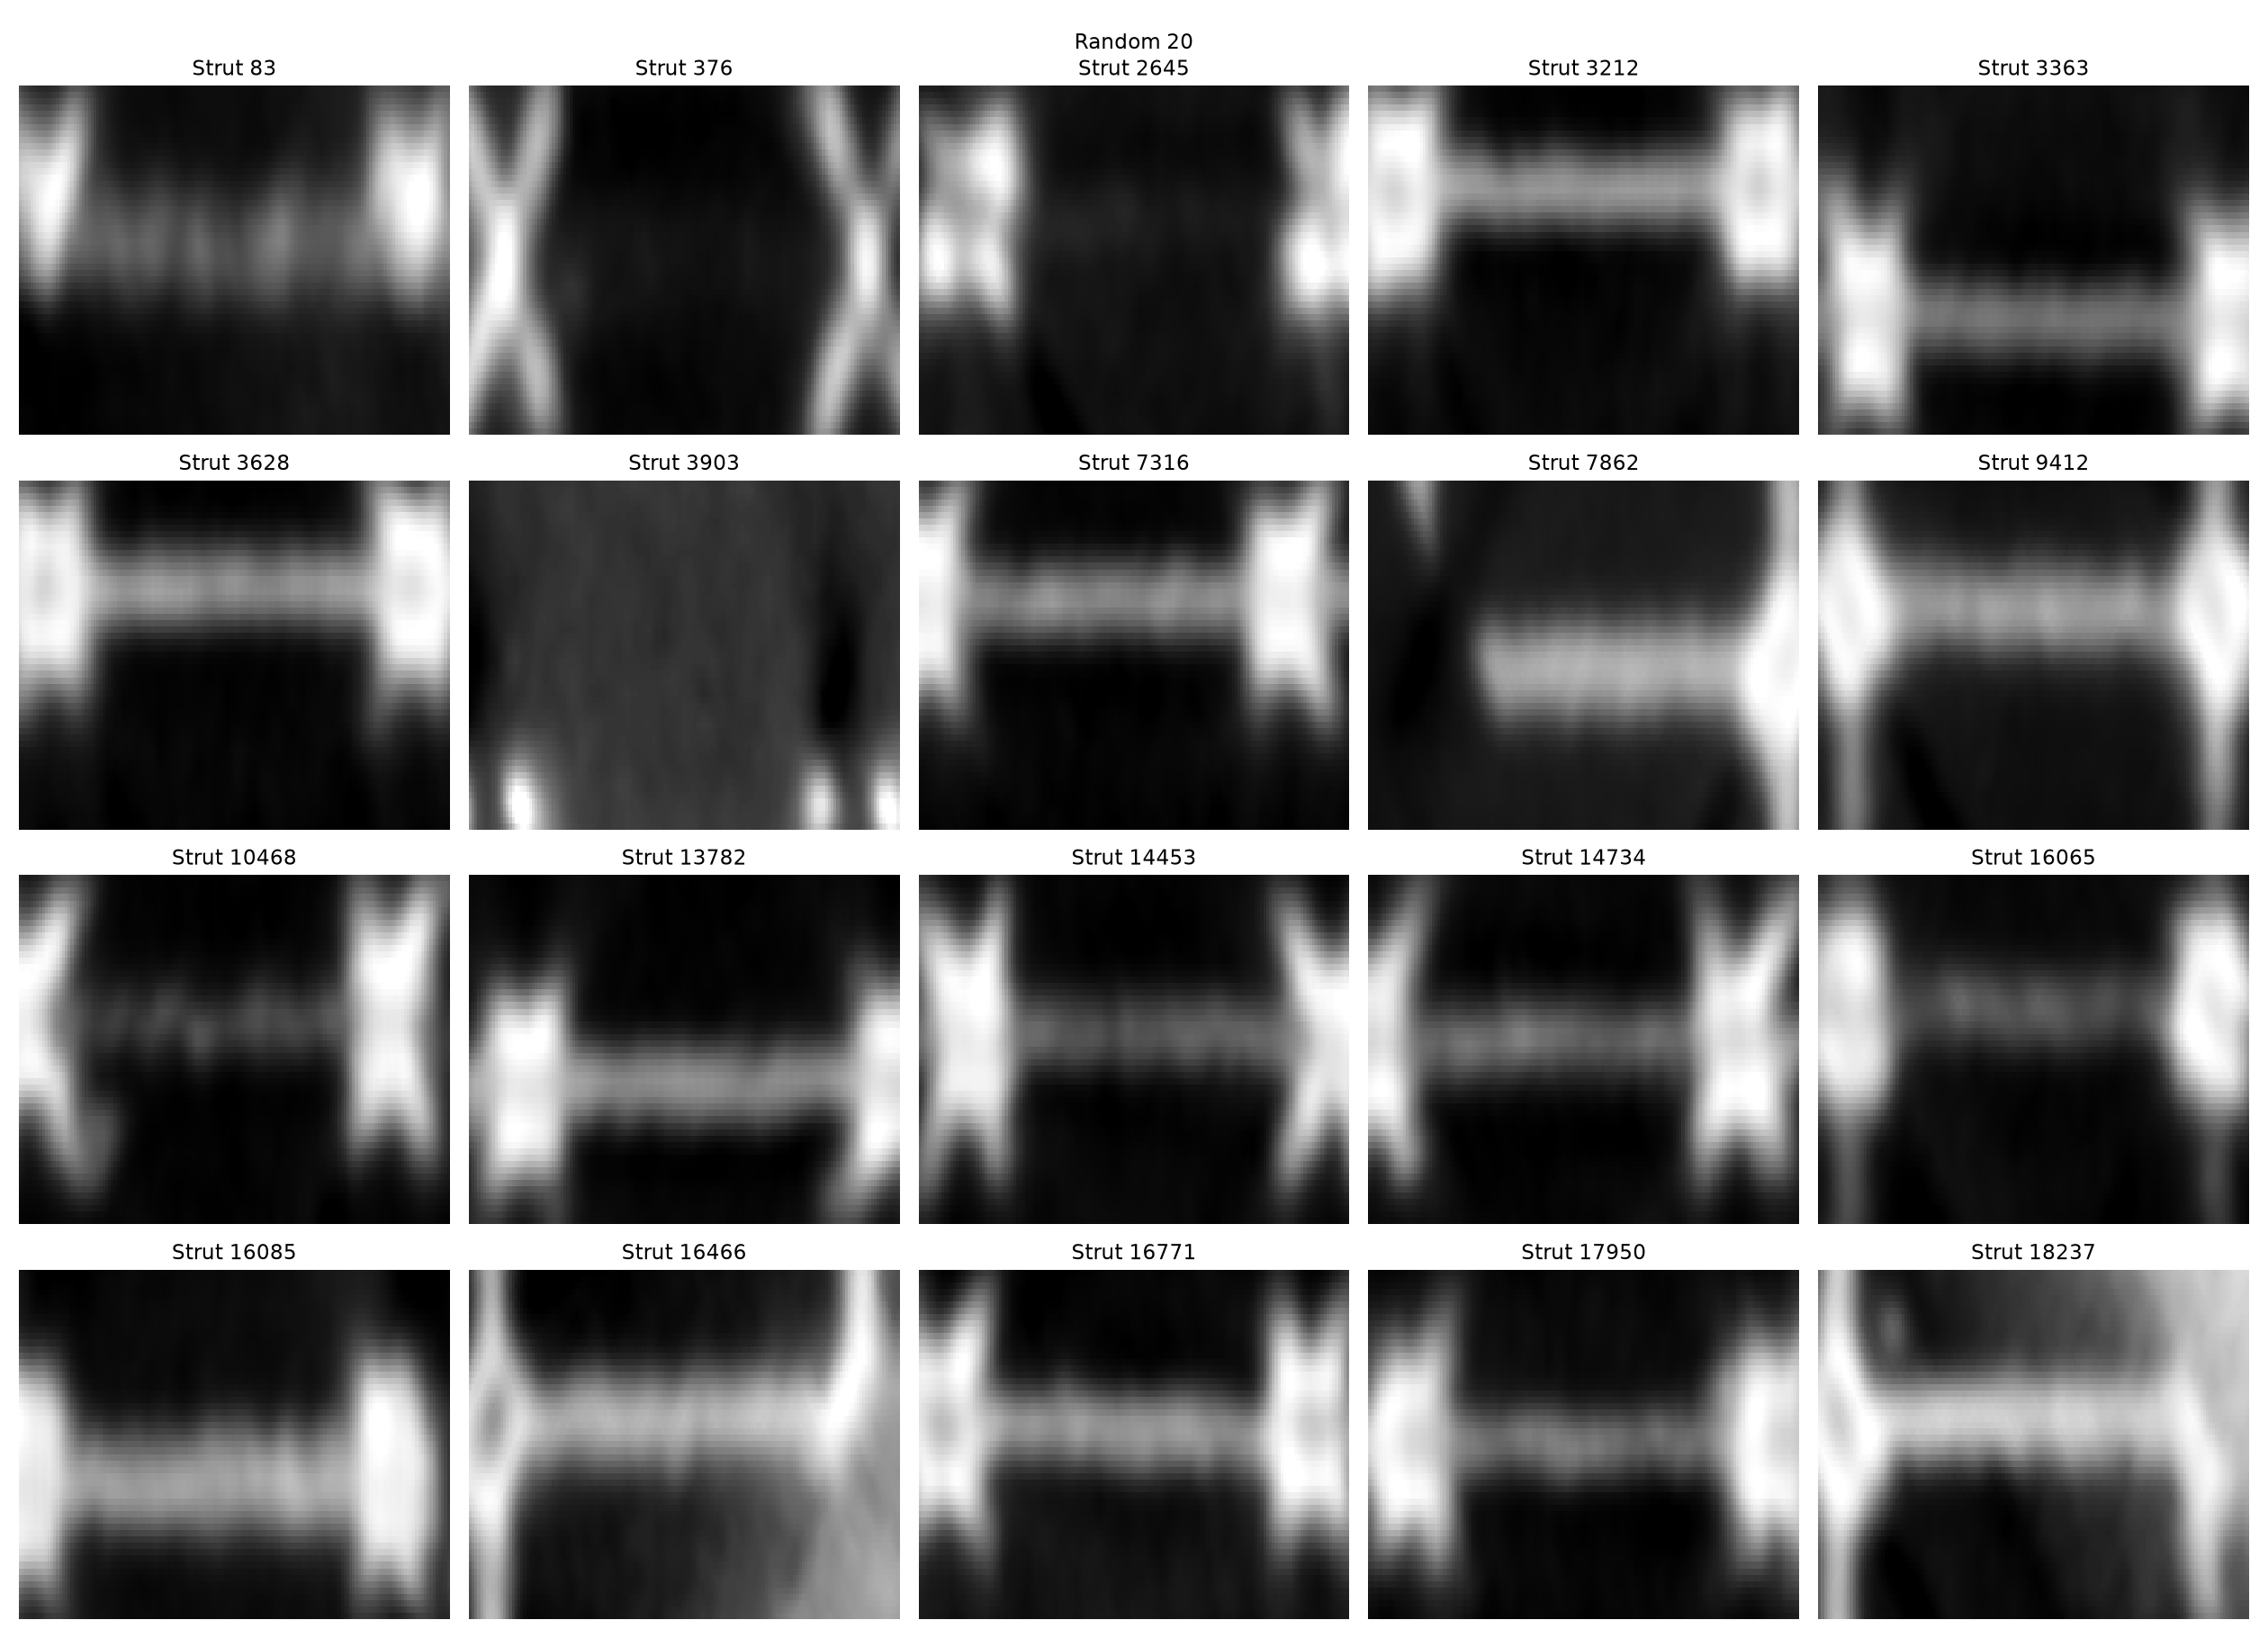

Preliminary gap-candidate summary:


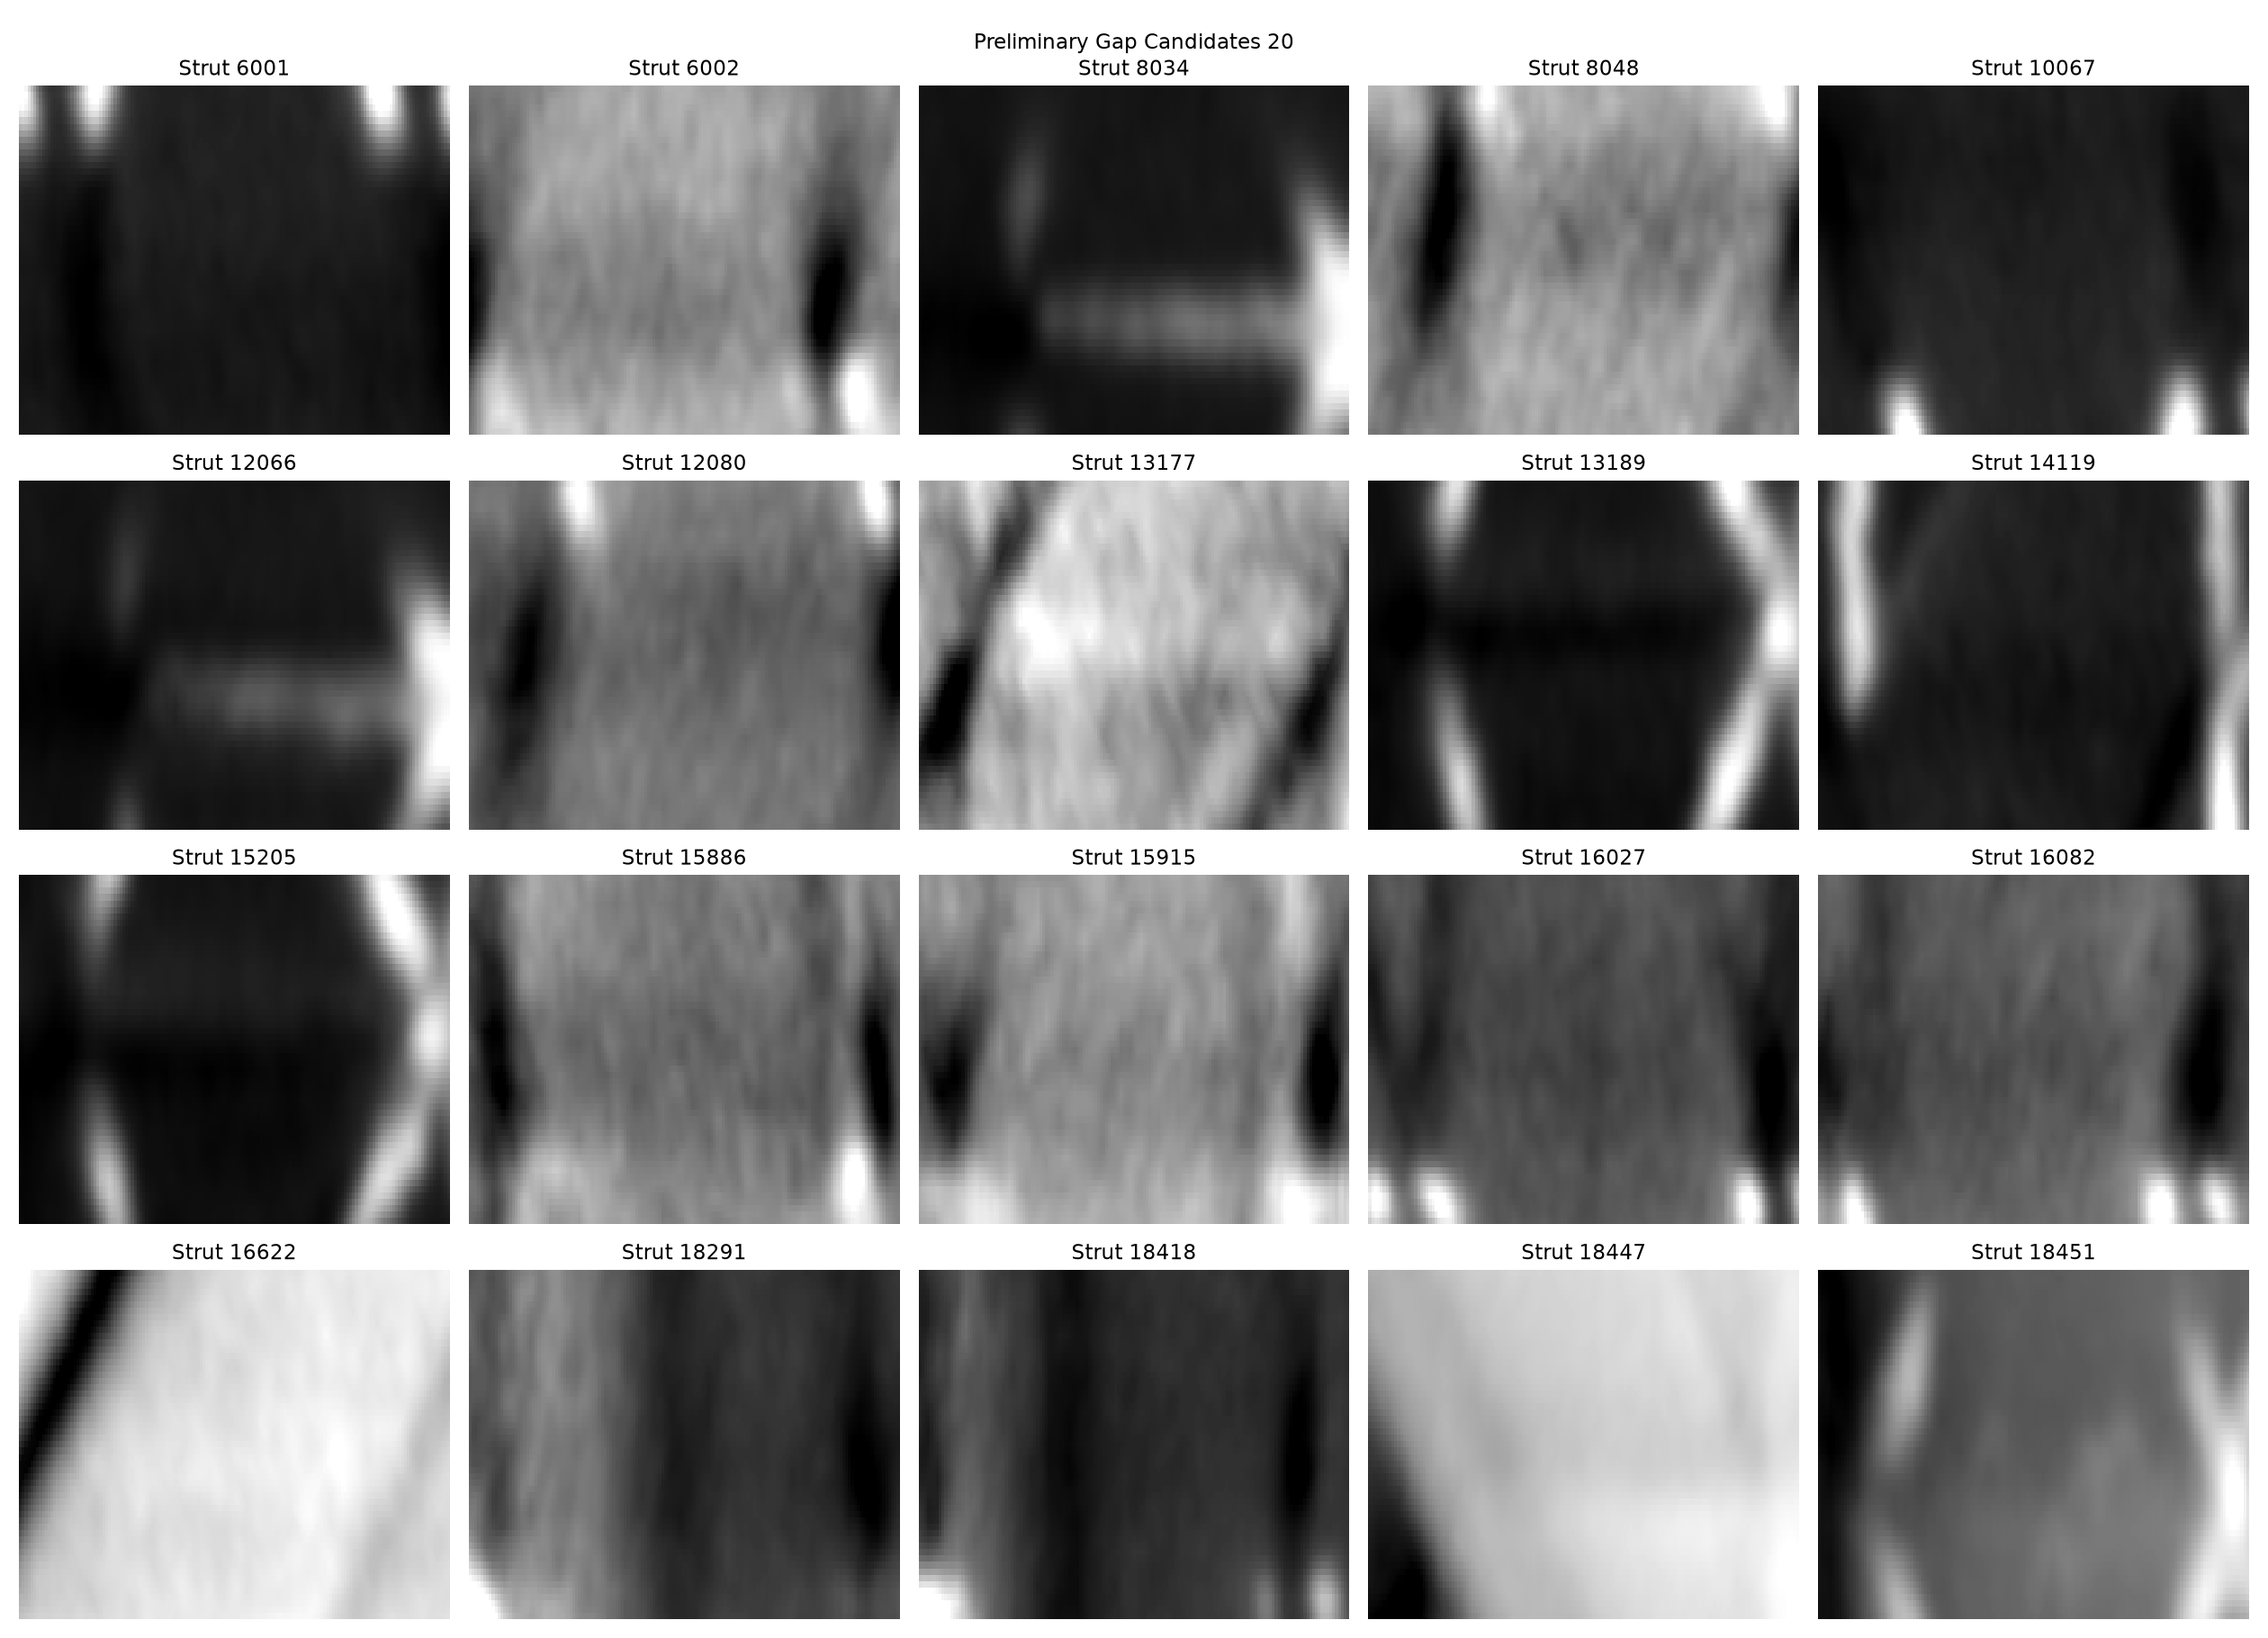


Detailed panels are saved under: data/missing_struts/analysis/random_gap_review/images
Record your manual decision as continuous, discontinuous, or uncertain in:
data/missing_struts/analysis/random_gap_review/selected_struts_for_review.csv


In [16]:
random_summary = generate_group_images(random_ids, "random_20")
gap_summary = generate_group_images(gap_candidate_ids, "preliminary_gap_candidates_20")

print("Random sample summary:")
if Image is not None:
    display(Image(filename=str(random_summary)))
else:
    print(random_summary)

print("Preliminary gap-candidate summary:")
if Image is not None:
    display(Image(filename=str(gap_summary)))
else:
    print(gap_summary)

print("\nDetailed panels are saved under:", IMAGE_DIR)
print("Record your manual decision as continuous, discontinuous, or uncertain in:")
print(OUTPUT_DIR / "selected_struts_for_review.csv")